In [ ]:
# ================================================
# CODE 1 — Upload & Prepare Dataset from Google Drive
# ================================================

# Import required libraries
#os → Work with folders and file paths (create, walk through, etc.)
#ipfile → Open and extract .zip files
#glob → Find files matching a pattern (like *.jpg)
#shutil → Copy or move files
#random → Shuffle or randomly split data

# Step 1️⃣: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2️⃣: Automatically find crack.zip anywhere in Drive
search_name = "crack.zip"
zip_path = None

import os
import zipfile
import glob
import shutil
import random

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if search_name in files:
        zip_path = os.path.join(root, search_name)
        break

if zip_path!=None:
    print(f"✅ Found dataset zip file at: {zip_path}")
else:
    print("File Not found in your Drive")
    # Stop here to avoid further errors
    raise FileNotFoundError(f"{search_name} not found under /content/drive/MyDrive")

# Step 3️⃣: Extract the dataset into /content/dataset
extract_dir = "/content/dataset"
os.makedirs(extract_dir, exist_ok=True)

print("📦 Extracting zip file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("✅ Extracted successfully to", extract_dir)

# Step 4️⃣: Create train and validation folders
os.makedirs(f"{extract_dir}/train/crack", exist_ok=True)
os.makedirs(f"{extract_dir}/train/no_crack", exist_ok=True)
os.makedirs(f"{extract_dir}/val/crack", exist_ok=True)
os.makedirs(f"{extract_dir}/val/no_crack", exist_ok=True)
# we use exist ok = true to check if file already exist then do not show error just continue
# Step 5️⃣: Split dataset (60% train, 40% test)
def split_images(src, train_dst, val_dst):
    if not os.path.exists(src):
        print(f"Source folder not found: {src}")
        return
    imgs = glob.glob(f"{src}/*")
    if len(imgs) == 0:
        print(f"No images found in {src}")
        return
    random.shuffle(imgs)
    split = int(0.8 * len(imgs))
    for img in imgs[:split]:   #split: means aage wala split ie 80 and split 20 means piche wala split ie 20
        shutil.copy(img, train_dst)
    for img in imgs[split:]:
        shutil.copy(img, val_dst)

# Modify these paths to match your dataset folders inside the extracted zip
split_images(f"{extract_dir}/Positive", f"{extract_dir}/train/crack", f"{extract_dir}/val/crack")
split_images(f"{extract_dir}/Negative", f"{extract_dir}/train/no_crack", f"{extract_dir}/val/no_crack")

print("\n🎉 Dataset ready!")
print("Use this path in your training code:\n➡️ data_dir = '/content/dataset'")
!ls /content/dataset/train
!ls /content/dataset/val


Mounted at /content/drive
✅ Found dataset zip file at: /content/drive/MyDrive/Datasets/crack.zip
📦 Extracting zip file...
✅ Extracted successfully to /content/dataset
Source folder not found: /content/dataset/Positive
Source folder not found: /content/dataset/Negative

🎉 Dataset ready!
Use this path in your training code:
➡️ data_dir = '/content/dataset'
crack  no_crack
crack  no_crack


🔍 Checking folders in /content/dataset/crack
/content/dataset/crack -> 1 files
/content/dataset/crack/Positive -> 288 files
/content/dataset/crack/Negative -> 180 files
Found 468 files belonging to 2 classes.

🚀 Training model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5724 - loss: 0.6975 - val_accuracy: 0.6548 - val_loss: 0.6766
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5920 - loss: 0.6507 - val_accuracy: 0.6905 - val_loss: 0.4235
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5834 - loss: 0.4508 - val_accuracy: 0.9167 - val_loss: 0.2773
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9510 - loss: 0.3203 - val_accuracy: 0.9643 - val_loss: 0.2818
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.9801 - loss: 0.2894 - val_accuracy: 1.0000 - val_loss: 0.1709


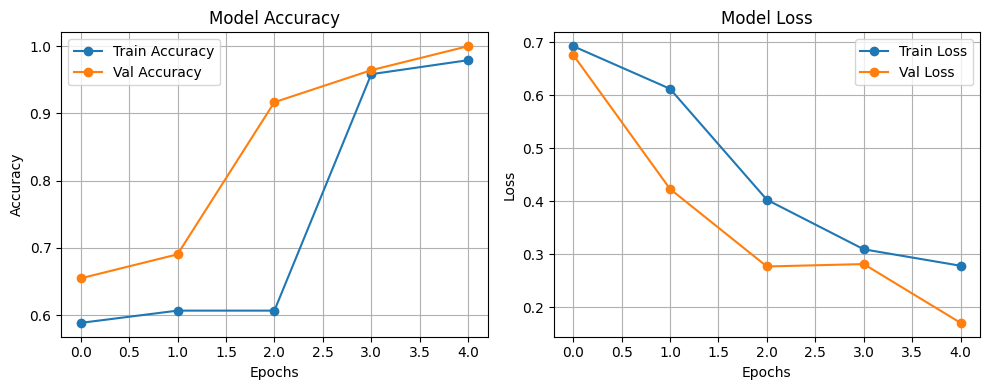

In [ ]:
# ================================================
#  CODE 2 : Train CNN + Plot + Print Results
# ================================================
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
#tensorflow as tf — imports TensorFlow (the library used to build and train neural networks). We call it tf so we can write tf.xxx.
#os — lets us talk to the operating system (list folders, count files, etc.).
#matplotlib.pyplot as plt — a library for drawing plots (graphs). We call it plt.
#numpy as np — a library for numerical operations (arrays, math).

# 🔹 Step 1: Dataset path
data_dir = "/content/dataset/crack"

print("🔍 Checking folders in", data_dir)
for root, dirs, files in os.walk(data_dir):
    print(root, "->", len(files), "files")

# 🔹 Step 2: Create dataset (auto detects Positive/Negative)
#keras is an advance api tool inside tensorflow which helps to build neural networks
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(64, 64),
    #making every image size 64 by 64 pixels and loading 16images at a time for speed
    batch_size=16,
    label_mode='int'# labels every batch of 16 image ine by one labelong each image as crack or no crack 0=crack 1=no_crack
)

# Split into training (80%) and validation (20%)
train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

# Prefetch for speed-While the model is training on one batch, TensorFlow loads the next batch in advance — so the GPU or CPU never sits idle.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 🔹 Step 3: Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3)),# pixels range from 1 to 255 we divide each from 255 to make it in range of 0 to 1 for stability
    tf.keras.layers.Conv2D(16, 3, activation='relu'), # convolution layer for image feature detection like edge and corner etc
    tf.keras.layers.MaxPooling2D(),#pooling means reducing image size and only keeping important part of it making processing faster and also prevents overfitting
    tf.keras.layers.Conv2D(32, 3, activation='relu'), #another conovlution layer now with 32 filters for more precise detection
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(), #makes 2d data into 1d data because next layer ie dense expects 1d data
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Step 4: Train model
print("\n🚀 Training model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

# 🔹 Step 5: Plot Accuracy & Loss
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o')
plt.plot(history.history.get('val_accuracy', []), label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='Train Loss', marker='o')
plt.plot(history.history.get('val_loss', []), label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()





📁 Loaded class names: ['crack', 'no_crack']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


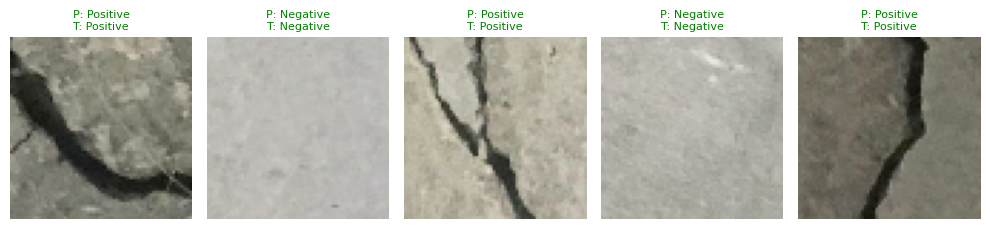


📸 Upload an image to test (jpg/png)...


In [ ]:
# =============================
# Prediction Section
# =============================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files
import random

# ⚙️ Store class names safely before prefetch (if not already done)
try:
    class_names
except NameError:
    # Recover class names manually from directory
    import os
    data_dir = '/content/dataset/train'
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    print(f"📁 Loaded class names: {class_names}")

class_names = dataset.class_names
plt.figure(figsize=(10, 6))
#random

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    for i in range(5):  # show 5 samples
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_label = np.argmax(preds[i])
        true_label = labels[i].numpy()
        color = "green" if pred_label == true_label else "red"
        plt.title(f"P: {class_names[pred_label]}\nT: {class_names[true_label]}",
                  color=color, fontsize=8)
        plt.axis("off")

plt.tight_layout()
plt.show()

# ✅ 2️⃣ User Upload Prediction (Improved for Colab Upload)
print("\n📸 Upload an image to test (jpg/png)...")

uploaded = files.upload()

# detect if model output is sigmoid or softmax
output_shape = model.output_shape[-1]
is_sigmoid = (output_shape == 1)
print(f"🧠 Model output type: {'sigmoid' if is_sigmoid else 'softmax'}")

for fn in uploaded.keys():
    img_path = '/content/' + fn

    # 🖼 Load & preprocess same as training pipeline
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img)

    # Handle grayscale (convert to RGB)
    if img_array.shape[-1] == 1:
        img_array = np.repeat(img_array, 3, axis=-1)

    # Normalize properly (same as training data)
    img_array = img_array.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 🔍 Debug info
    print(f"\nImage '{fn}' loaded — min={img_array.min():.3f}, max={img_array.max():.3f}")

    # ✅ Predict
    preds = model.predict(img_array)
    print("Raw model output:", preds)

    if is_sigmoid:
        prob = preds[0][0]
        predicted_label = class_names[1] if prob > 0.5 else class_names[0]
        confidence = prob if prob > 0.5 else 1 - prob
    else:  # softmax
        idx = np.argmax(preds[0])
        predicted_label = class_names[idx]
        confidence = preds[0][idx]

    # 🖼 Display result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"🧠 Predicted: {predicted_label}\n", color='green')
    plt.show()

    print(f"\n✅ Final Prediction: {predicted_label} ")


In [ ]:
from tensorflow.keras.preprocessing import image
